In [ ]:
from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus
from gentropy.dataset.variant_index import VariantIndex
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment
from pyspark.sql import functions as f


Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [ ]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/17 15:39:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/17 15:39:16 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [ ]:
path_to_release_folder = "../../../data/25.06/"
path_to_intermediate_data_folder = "../../../data/intermediate_files/"

sl = StudyLocus.from_parquet(session, path_to_release_folder + "output/credible_set")
si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study")

sl_eff = session.spark.read.parquet(path_to_intermediate_data_folder + "lead_variant_effect")

l2g_full = session.spark.read.parquet(
    path_to_intermediate_data_folder + "list_of_prioritised_genes_per_CS_with_year_nfe_maf.parquet"
)


# Gene staruration plot


In [ ]:
l2g_full.show(1)


+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------+----------------+-------------------+----+------+-------------+----------+--------------+----+
|             studyId|        studyLocusId|         geneId|             score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                maf|       variantId|            absBeta|year|is_nfe|   diseaseIds|nfe_common|non_nfe_common|rare|
+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------+----------------+-------------------+----+------+-------------+----------+--------------+----+
|FINNGEN_R12_CD2_B...|1d7173e340d92962f...|ENSG00000103489|0.8031893968582153|         0|         0|  0|          1|0.10647321428571428|16_17260032_AT_A|0.32108576429510277|2024|     0|[EFO_0009675]|         0|             1|   0|
+--------------------+--------------------+---------------+-----------------

In [ ]:
qm_cs = (
    session.spark.read.parquet(path_to_intermediate_data_folder + "qualifying_measurement_credible_sets")
    .select("studyLocusId")
    .cache()
)
qm_cs.count()


450357

In [ ]:
qd_cs = (
    session.spark.read.parquet(path_to_intermediate_data_folder + "qualifying_credible_sets")
    .select("studyLocusId")
    .cache()
)
qd_cs.count()


70618

In [ ]:
qcs = qm_cs.unionByName(qd_cs)
qcs.count()


520975

In [ ]:
l2g_full.join(qd_cs, on="studyLocusId", how="inner").select("geneId").distinct().count()


8285

In [ ]:
l2g_diseases_measurements_full = l2g_full.join(qcs, on="studyLocusId", how="inner").toPandas()


In [ ]:
l2g_diseases_full = l2g_full.join(qd_cs, on="studyLocusId", how="inner").toPandas()
l2g_diseases_full


,studyLocusId,studyId,geneId,score,eQTL_coloc,pQTL_coloc,VEP,distanceTSS,maf,variantId,absBeta,year,is_nfe,diseaseIds,nfe_common,non_nfe_common,rare
0,1d7173e340d92962f54379a8b83411ab,FINNGEN_R12_CD2_BENIGN_MELANOCYTIC_LOWERLIMB,ENSG00000103489,0.803189,0,0,0,1,0.106473,16_17260032_AT_A,0.321086,2024,0,[EFO_0009675],0,1,0
1,cc864df137599ffa3c0fcd8c3357b3b5,FINNGEN_R12_CD2_BENIGN_MELANOCYTIC_LOWERLIMB,ENSG00000003249,0.763560,0,0,0,1,0.460391,16_90010438_G_C,0.225577,2024,0,[EFO_0009675],0,1,0
2,30c93b4220d8fa492ad706e4c3b5b126,FINNGEN_R12_J10_RESPOTHER,ENSG00000148426,0.848641,1,0,0,1,0.152826,10_11876598_G_GTGTGTA,0.117262,2024,0,[EFO_0000684],0,1,0
3,69a3f362881274e9267a415c80b0d30b,FINNGEN_R12_J10_RESPOTHER,ENSG00000080644,0.309787,1,0,0,1,0.378176,15_78618839_T_C,0.093240,2024,0,[EFO_0000684],0,1,0
4,85b6a4d6578c4c7d240d6597e2f3e764,GCST000141,ENSG00000123411,0.216042,1,0,0,1,0.327131,12_56018703_T_G,0.452674,2008,1,[MONDO_0005147],1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70395,c5b136e65a4426125dbe2d899f3edccb,GCST90480315,ENSG00000115380,0.937875,1,1,0,1,0.239888,2_55869757_A_G,0.150472,2024,0,[HP_0004872],0,1,0
70396,f163becffbfe4bcff2f7fbcf3303bdcc,GCST90480315,ENSG00000112297,0.712141,0,0,0,1,0.462406,6_106487956_A_G,0.084295,2024,0,[HP_0004872],0,1,0
70397,724dc1fa9b539bd5e366f269b5f14fd6,GCST90480315,ENSG00000115380,0.672488,1,0,0,1,0.122489,2_55812964_T_C,0.159138,2024,0,[HP_0004872],0,1,0
70398,7e947667bb7257e2a51e060552e9b95f,GCST90480315,ENSG00000123219,0.499467,1,0,0,1,0.249479,5_65551070_C_T,0.157043,2024,0,[HP_0004872],0,1,0


In [ ]:
l2g_measurements_full = l2g_full.join(qm_cs, on="studyLocusId", how="inner").toPandas()
l2g_measurements_full


,studyLocusId,studyId,geneId,score,eQTL_coloc,pQTL_coloc,VEP,distanceTSS,maf,variantId,absBeta,year,is_nfe,diseaseIds,nfe_common,non_nfe_common,rare
0,0002cd1632205979d9155eaf192c868c,GCST004567,ENSG00000112715,0.351263,0,0,0,1,0.480536,6_43790159_C_A,0.033645,2017,1,"[EFO_0007788, EFO_0008002]",1,0,0
1,0003696a50893286fa2b9eaaf753b054,GCST90302030,ENSG00000103569,0.626518,0,0,0,1,0.001632,15_58207366_G_T,0.450297,2024,0,[EFO_0020947],0,0,1
2,0005218bc3a62e3875f2ba0a0b63c349,GCST90014010,ENSG00000099337,0.846704,0,0,1,1,0.025813,19_38320104_C_G,0.037586,2021,1,[EFO_0010968],1,0,0
3,00063cca492e89f3908e7933e3f4782c,GCST90445976,ENSG00000145850,0.929139,1,1,0,1,0.372730,5_156964617_T_C,0.040134,2024,1,[EFO_0022183],1,0,0
4,0006c16ca61e0c2e5c65eefadbd04ff8,GCST90475159,ENSG00000188191,0.625339,1,0,0,0,0.406800,7_631956_C_CA,0.012499,2024,1,[EFO_0004340],1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453004,ff6eedeb4998ec458f2d35807f69a78a,GCST90479714,ENSG00000162595,0.694608,0,0,0,1,0.010001,1_68054537_G_C,0.075077,2024,0,[EFO_0004833],0,1,0
453005,ff71ff403887eb425369b3709b33260d,GCST90310184,ENSG00000220948,0.561281,0,0,1,1,0.067012,11_48993235_T_C,0.031002,2025,1,[EFO_0004530],1,0,0
453006,ff73a37577d26bb6abc0933c77815f1f,GCST90476400,ENSG00000169592,0.177819,1,0,0,0,0.477315,16_29983601_C_T,0.014288,2024,1,[EFO_0006335],1,0,0
453007,ffaa2c5a1627506fa8076de0d1e2b973,GCST004608,ENSG00000100300,0.822599,1,0,0,1,0.325057,22_43155001_C_T,0.021026,2016,1,[EFO_0007997],1,0,0


In [ ]:
# Get unique geneIds from each DataFrame
genes_measurements = set(l2g_measurements_full["geneId"].unique())
genes_diseases = set(l2g_diseases_full["geneId"].unique())

# Calculate counts
print(f"Unique genes in measurements: {len(genes_measurements)}")
print(f"Unique genes in diseases: {len(genes_diseases)}")

# Calculate overlap
overlap = genes_measurements.intersection(genes_diseases)
print(f"Overlap between sets: {len(overlap)}")

# Calculate genes unique to each set
measurements_only = genes_measurements - genes_diseases
diseases_only = genes_diseases - genes_measurements

print(f"Genes only in measurements: {len(measurements_only)}")
print(f"Genes only in diseases: {len(diseases_only)}")

# Calculate percentages
total_unique = len(genes_measurements.union(genes_diseases))
print(f"Total unique genes across both: {total_unique}")
print(f"Overlap percentage: {len(overlap) / total_unique * 100:.1f}%")


Unique genes in measurements: 15160
Unique genes in diseases: 8285
Overlap between sets: 7804
Genes only in measurements: 7356
Genes only in diseases: 481
Total unique genes across both: 15641
Overlap percentage: 49.9%


In [ ]:
def plot_cumulative_genes(table_to_plot, title):
    """Plot cumulative unique disease genes discovered per year by ancestry and MAF.

    Args:
        table_to_plot (DataFrame): DataFrame containing gene discovery data.

    """
    import matplotlib.pyplot as plt
    import pandas as pd

    # Assume table_to_plot is your DataFrame with columns: geneId, year, nfe_common, nfe_rare, not_nfe

    # 1. Get unique genes per year for each group
    def get_cumulative_genes(df, mask, year_col="year", gene_col="geneId"):
        filtered = df[mask][[gene_col, year_col]].drop_duplicates()
        # First year each gene appears
        first_year = filtered.groupby(gene_col)[year_col].min().reset_index()
        # Count new genes per year
        per_year = first_year.groupby(year_col).size().sort_index().rename("count").reset_index()
        # Cumulative sum
        per_year["cumulative"] = per_year["count"].cumsum()
        return per_year.set_index(year_col)

    # 1. nfe_common only
    cum_common_nfe = get_cumulative_genes(table_to_plot, table_to_plot["nfe_common"] == 1)

    # 2. nfe_common or non_nfe_common
    cum_common_all = get_cumulative_genes(
        table_to_plot, (table_to_plot["nfe_common"] == 1) | (table_to_plot["non_nfe_common"] == 1)
    )

    # 3. all rows
    cum_all = get_cumulative_genes(table_to_plot, table_to_plot["nfe_common"].notnull())  # or just table_to_plot

    # 2. Calculate incremental layers
    years = sorted(set(cum_common_nfe.index) | set(cum_common_all.index) | set(cum_all.index))
    df_plot = pd.DataFrame(index=years)
    df_plot["nfe_common"] = cum_common_nfe["cumulative"].reindex(years, fill_value=0)
    df_plot["all_common"] = cum_common_all["cumulative"].reindex(years, fill_value=0)
    df_plot["all"] = cum_all["cumulative"].reindex(years, fill_value=0)

    # Calculate increments for stacking
    df_plot["layer1"] = df_plot["nfe_common"]
    df_plot["layer2"] = df_plot["all_common"] - df_plot["nfe_common"]
    df_plot["layer3"] = df_plot["all"] - df_plot["all_common"]

    df_plot.index = df_plot.index.astype(float).astype(int).astype(str)
    # 3. Plot
    plt.figure(figsize=(5, 4))
    plt.bar(df_plot.index, df_plot["layer1"], color="royalblue", label="NFE common (MAF≥0.01)")
    plt.bar(
        df_plot.index,
        df_plot["layer2"],
        bottom=df_plot["layer1"],
        color="lightgreen",
        label="Non-NFE common (MAF≥0.01)",
    )
    plt.bar(
        df_plot.index,
        df_plot["layer3"],
        bottom=df_plot["layer1"] + df_plot["layer2"],
        color="orange",
        label="Rare (MAF<0.01)",
    )
    plt.xlabel("Year")
    plt.ylabel("Cumulative unique genes")
    plt.title(title)
    plt.legend()
    plt.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.7)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_cumulative_genes1(table_to_plot, title):
    """Plot cumulative unique disease genes discovered per year by ancestry and MAF using lines.

    Args:
        table_to_plot (DataFrame): DataFrame containing gene discovery data.

    """
    import matplotlib.pyplot as plt
    import pandas as pd

    # 1. Get unique genes per year for each group
    def get_cumulative_genes(df, mask, year_col="year", gene_col="geneId"):
        filtered = df[mask][[gene_col, year_col]].drop_duplicates()
        filtered = filtered[filtered["year"] != 2025]
        # First year each gene appears
        first_year = filtered.groupby(gene_col)[year_col].min().reset_index()
        # Count new genes per year
        per_year = first_year.groupby(year_col).size().sort_index().rename("count").reset_index()
        # Cumulative sum
        per_year["cumulative"] = per_year["count"].cumsum()
        return per_year.set_index(year_col)

    # 1. nfe_common only
    cum_common_nfe = get_cumulative_genes(table_to_plot, table_to_plot["nfe_common"] == 1)

    # 2. nfe_common or non_nfe_common
    cum_common_all = get_cumulative_genes(
        table_to_plot, (table_to_plot["nfe_common"] == 1) | (table_to_plot["non_nfe_common"] == 1)
    )

    # 3. all rows
    cum_all = get_cumulative_genes(table_to_plot, table_to_plot["nfe_common"].notnull())

    # Prepare data for plotting
    years = sorted(set(cum_common_nfe.index) | set(cum_common_all.index) | set(cum_all.index))
    df_plot = pd.DataFrame(index=years)
    df_plot["nfe_common"] = cum_common_nfe["cumulative"].reindex(years, fill_value=0)
    df_plot["all_common"] = cum_common_all["cumulative"].reindex(years, fill_value=0)
    df_plot["all"] = cum_all["cumulative"].reindex(years, fill_value=0)

    # Convert index to string for plotting
    df_plot.index = df_plot.index.astype(float).astype(int).astype(str)

    # Create the plot with lines
    plt.figure(figsize=(5, 4))

    # Plot lines with markers
    plt.plot(
        df_plot.index,
        df_plot["nfe_common"],
        marker="o",
        linewidth=1.5,
        markersize=4,
        color="royalblue",
        label="NFE common (MAF≥0.01)",
    )

    plt.plot(
        df_plot.index,
        df_plot["all_common"],
        marker="s",
        linewidth=1.5,
        markersize=4,
        color="forestgreen",
        label="All common (MAF≥0.01)",
    )

    plt.plot(
        df_plot.index,
        df_plot["all"],
        marker="^",
        linewidth=1.5,
        markersize=4,
        color="darkorange",
        label="All (including rare)",
    )

    # Add fill between lines for visual appeal
    plt.fill_between(df_plot.index, 0, df_plot["nfe_common"], alpha=0.2, color="royalblue")
    plt.fill_between(df_plot.index, df_plot["nfe_common"], df_plot["all_common"], alpha=0.2, color="forestgreen")
    plt.fill_between(df_plot.index, df_plot["all_common"], df_plot["all"], alpha=0.15, color="darkorange")

    # Styling
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Unique genes", fontsize=12)
    plt.title(title, fontsize=13, fontweight="bold")
    plt.legend(fontsize=10, frameon=True, fancybox=True, shadow=False)
    plt.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.7, alpha=0.7)
    plt.xticks(rotation=45, fontsize=10)
    plt.yticks(fontsize=10)

    # Add subtle background color
    plt.gca().set_facecolor("#fafafa")

    plt.tight_layout()
    plt.show()
    print(df_plot)


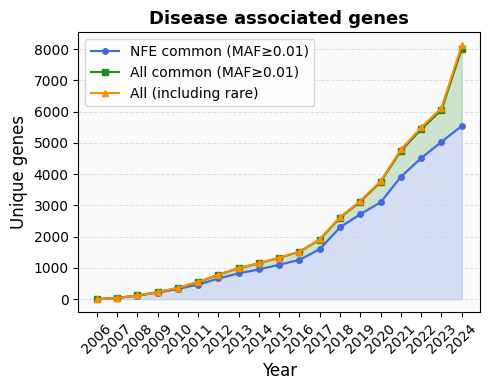

      nfe_common  all_common   all
2006           1           1     1
2007          41          41    41
2008         118         119   119
2009         211         227   227
2010         330         360   360
2011         469         551   552
2012         663         785   787
2013         830         993   996
2014         951        1148  1152
2015        1107        1327  1332
2016        1257        1519  1525
2017        1605        1909  1923
2018        2301        2608  2629
2019        2722        3124  3145
2020        3101        3755  3781
2021        3919        4747  4789
2022        4513        5437  5494
2023        5035        6056  6119
2024        5545        8014  8129


In [ ]:
plot_cumulative_genes1(l2g_diseases_full, title="Disease associated genes")


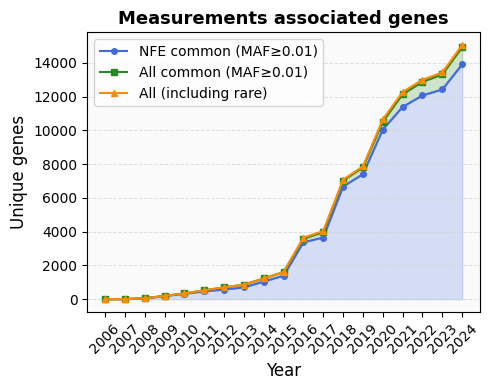

      nfe_common  all_common    all
2006           1           1      1
2007           5           5      5
2008          51          52     52
2009         190         196    196
2010         321         342    342
2011         467         525    525
2012         570         701    701
2013         697         861    861
2014        1045        1231   1231
2015        1391        1610   1612
2016        3372        3585   3648
2017        3655        3972   4039
2018        6676        7030   7090
2019        7409        7810   7871
2020       10051       10520  10654
2021       11396       12149  12280
2022       12074       12875  13005
2023       12430       13320  13436
2024       13914       14930  15061


In [ ]:
plot_cumulative_genes1(l2g_measurements_full, title="Measurements associated genes")


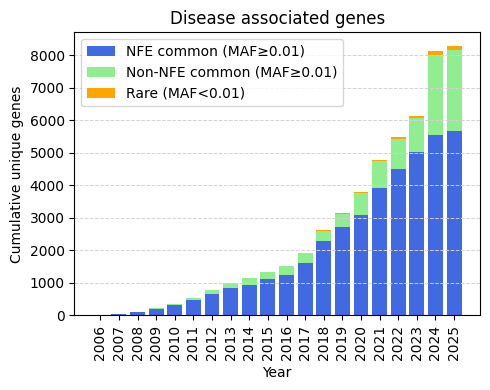

In [ ]:
plot_cumulative_genes(l2g_diseases_full, title="Disease associated genes")


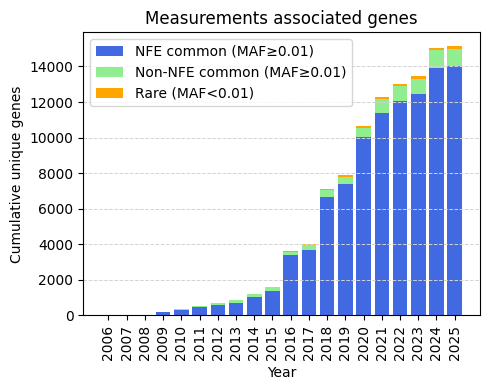

In [ ]:
plot_cumulative_genes(l2g_measurements_full, title="Measurements associated genes")


In [ ]:
def plot_cumulative_gene_disease_pairs(table_to_plot, title):
    """Plot cumulative unique gene-disease pairs discovered per year by ancestry and MAF.

    Args:
        table_to_plot (DataFrame): DataFrame containing gene discovery data with diseaseIds column.

    """
    import matplotlib.pyplot as plt
    import pandas as pd

    # First explode diseaseIds to get individual gene-disease pairs
    table_exploded = table_to_plot.explode("diseaseIds")
    # table_exploded = table_to_plot

    # 1. Get unique gene-disease pairs per year for each group
    def get_cumulative_gene_disease_pairs(df, mask, year_col="year"):
        filtered = df[mask][["geneId", "diseaseIds", year_col]].drop_duplicates()
        # Create gene-disease pair identifier
        filtered["gene_disease_pair"] = filtered["geneId"] + "_" + filtered["diseaseIds"]
        # First year each gene-disease pair appears
        first_year = filtered.groupby("gene_disease_pair")[year_col].min().reset_index()
        # Count new pairs per year
        per_year = first_year.groupby(year_col).size().sort_index().rename("count").reset_index()
        # Cumulative sum
        per_year["cumulative"] = per_year["count"].cumsum()
        return per_year.set_index(year_col)

    # 1. nfe_common only
    cum_common_nfe = get_cumulative_gene_disease_pairs(table_exploded, table_exploded["nfe_common"] == 1)

    # 2. nfe_common or non_nfe_common
    cum_common_all = get_cumulative_gene_disease_pairs(
        table_exploded, (table_exploded["nfe_common"] == 1) | (table_exploded["non_nfe_common"] == 1)
    )

    # 3. all rows
    cum_all = get_cumulative_gene_disease_pairs(table_exploded, table_exploded["nfe_common"].notnull())

    # 2. Calculate incremental layers
    years = sorted(set(cum_common_nfe.index) | set(cum_common_all.index) | set(cum_all.index))
    df_plot = pd.DataFrame(index=years)
    df_plot["nfe_common"] = cum_common_nfe["cumulative"].reindex(years, fill_value=0)
    df_plot["all_common"] = cum_common_all["cumulative"].reindex(years, fill_value=0)
    df_plot["all"] = cum_all["cumulative"].reindex(years, fill_value=0)

    # Calculate increments for stacking
    df_plot["layer1"] = df_plot["nfe_common"]
    df_plot["layer2"] = df_plot["all_common"] - df_plot["nfe_common"]
    df_plot["layer3"] = df_plot["all"] - df_plot["all_common"]

    df_plot.index = df_plot.index.astype(float).astype(int).astype(str)

    # 3. Plot
    plt.figure(figsize=(5, 4))
    plt.bar(df_plot.index, df_plot["layer1"], color="royalblue", label="NFE common (MAF≥0.01)")
    plt.bar(
        df_plot.index,
        df_plot["layer2"],
        bottom=df_plot["layer1"],
        color="lightgreen",
        label="Non-NFE common (MAF≥0.01)",
    )
    plt.bar(
        df_plot.index,
        df_plot["layer3"],
        bottom=df_plot["layer1"] + df_plot["layer2"],
        color="orange",
        label="Rare (MAF<0.01)",
    )
    plt.xlabel("Year")
    plt.ylabel("Cumulative number of pairs")
    plt.title(title)
    plt.legend()
    plt.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.7)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_cumulative_gene_disease_pairs1(table_to_plot, title):
    """Plot cumulative unique gene-disease pairs discovered per year by ancestry and MAF using lines.

    Args:
        table_to_plot (DataFrame): DataFrame containing gene discovery data with diseaseIds column.

    """
    import matplotlib.pyplot as plt
    import pandas as pd

    # First explode diseaseIds to get individual gene-disease pairs
    table_exploded = table_to_plot.explode("diseaseIds")

    # 1. Get unique gene-disease pairs per year for each group
    def get_cumulative_gene_disease_pairs(df, mask, year_col="year"):
        filtered = df[mask][["geneId", "diseaseIds", year_col]].drop_duplicates()
        # Filter out 2025 data if present
        filtered = filtered[filtered["year"] != 2025] if 2025 in filtered["year"].values else filtered
        # Create gene-disease pair identifier
        filtered["gene_disease_pair"] = filtered["geneId"] + "_" + filtered["diseaseIds"]
        # First year each gene-disease pair appears
        first_year = filtered.groupby("gene_disease_pair")[year_col].min().reset_index()
        # Count new pairs per year
        per_year = first_year.groupby(year_col).size().sort_index().rename("count").reset_index()
        # Cumulative sum
        per_year["cumulative"] = per_year["count"].cumsum()
        return per_year.set_index(year_col)

    # 1. nfe_common only
    cum_common_nfe = get_cumulative_gene_disease_pairs(table_exploded, table_exploded["nfe_common"] == 1)

    # 2. nfe_common or non_nfe_common
    cum_common_all = get_cumulative_gene_disease_pairs(
        table_exploded, (table_exploded["nfe_common"] == 1) | (table_exploded["non_nfe_common"] == 1)
    )

    # 3. all rows
    cum_all = get_cumulative_gene_disease_pairs(table_exploded, table_exploded["nfe_common"].notnull())

    # Prepare data for plotting
    years = sorted(set(cum_common_nfe.index) | set(cum_common_all.index) | set(cum_all.index))
    df_plot = pd.DataFrame(index=years)
    df_plot["nfe_common"] = cum_common_nfe["cumulative"].reindex(years, fill_value=0)
    df_plot["all_common"] = cum_common_all["cumulative"].reindex(years, fill_value=0)
    df_plot["all"] = cum_all["cumulative"].reindex(years, fill_value=0)

    # Convert index to string for plotting
    df_plot.index = df_plot.index.astype(float).astype(int).astype(str)

    # Create the plot with lines
    plt.figure(figsize=(5, 4))

    # Plot lines with markers
    plt.plot(
        df_plot.index,
        df_plot["nfe_common"],
        marker="o",
        linewidth=1.5,
        markersize=4,
        color="royalblue",
        label="NFE common (MAF≥0.01)",
    )

    plt.plot(
        df_plot.index,
        df_plot["all_common"],
        marker="s",
        linewidth=1.5,
        markersize=4,
        color="forestgreen",
        label="All common (MAF≥0.01)",
    )

    plt.plot(
        df_plot.index,
        df_plot["all"],
        marker="^",
        linewidth=1.5,
        markersize=4,
        alpha=0.7,
        color="darkorange",
        label="All (including rare)",
    )

    # Add fill between lines for visual appeal
    plt.fill_between(df_plot.index, 0, df_plot["nfe_common"], alpha=0.2, color="royalblue")
    plt.fill_between(df_plot.index, df_plot["nfe_common"], df_plot["all_common"], alpha=0.2, color="forestgreen")
    plt.fill_between(df_plot.index, df_plot["all_common"], df_plot["all"], alpha=0.15, color="darkorange")

    # Styling
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Number of pairs", fontsize=12)
    plt.title(title, fontsize=13, fontweight="bold")
    plt.legend(fontsize=10, frameon=True, fancybox=True, shadow=True)
    plt.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.7, alpha=0.7)
    plt.xticks(rotation=45, fontsize=10)
    plt.yticks(fontsize=10)

    # Add subtle background color
    plt.gca().set_facecolor("#fafafa")

    plt.tight_layout()
    plt.show()
    print(df_plot)


In [ ]:
table_exploded = l2g_measurements_full.explode("diseaseIds")

# 1. Get unique gene-disease pairs per year for each group


def get_cumulative_gene_disease_pairs(df, mask, year_col="year"):
    filtered = df[mask][["geneId", "diseaseIds", year_col]].drop_duplicates()
    # Create gene-disease pair identifier
    filtered["gene_disease_pair"] = filtered["geneId"] + "_" + filtered["diseaseIds"]
    # First year each gene-disease pair appears
    first_year = filtered.groupby("gene_disease_pair")[year_col].min().reset_index()
    # Count new pairs per year
    per_year = first_year.groupby(year_col).size().sort_index().rename("count").reset_index()
    # Cumulative sum
    per_year["cumulative"] = per_year["count"].cumsum()
    return per_year.set_index(year_col)


cum_all = get_cumulative_gene_disease_pairs(table_exploded, table_exploded["nfe_common"].notnull())


In [ ]:
cum_all


,count,cumulative
year,,
2006,1,1
2007,4,5
2008,56,61
2009,177,238
2010,203,441
2011,260,701
2012,304,1005
2013,322,1327
2014,843,2170


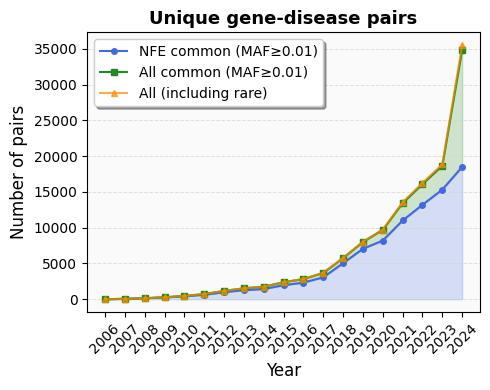

      nfe_common  all_common    all
2006           1           1      1
2007          46          46     46
2008         130         131    131
2009         248         268    268
2010         412         452    452
2011         616         722    723
2012         979        1159   1161
2013        1260        1522   1525
2014        1420        1744   1750
2015        1955        2373   2382
2016        2323        2813   2823
2017        3054        3676   3699
2018        5037        5742   5777
2019        7051        8003   8040
2020        8199        9688   9738
2021       11005       13429  13560
2022       13202       16100  16275
2023       15323       18670  18878
2024       18504       34905  35535


In [ ]:
plot_cumulative_gene_disease_pairs1(l2g_diseases_full, title="Unique gene-disease pairs")


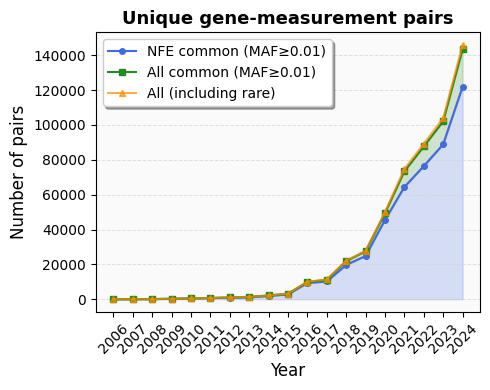

      nfe_common  all_common     all
2006           1           1       1
2007           5           5       5
2008          59          61      61
2009         231         238     238
2010         409         441     441
2011         621         701     701
2012         807        1005    1005
2013        1065        1327    1327
2014        1838        2169    2170
2015        2733        3159    3164
2016        9302        9879   10059
2017       10159       11115   11309
2018       19677       21891   22123
2019       24772       27511   27767
2020       45467       49336   50113
2021       64405       73412   74743
2022       76400       87660   89286
2023       88895      102085  103968
2024      121898      143372  145897


In [ ]:
plot_cumulative_gene_disease_pairs1(l2g_measurements_full, title="Unique gene-measurement pairs")


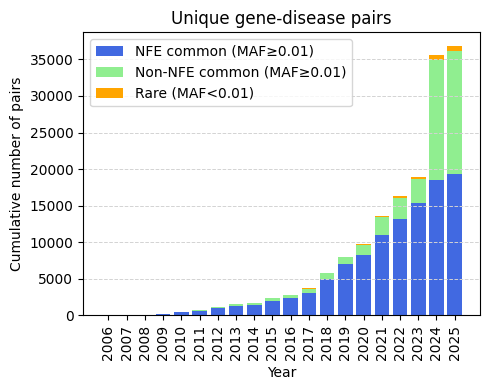

In [ ]:
plot_cumulative_gene_disease_pairs(l2g_diseases_full, title="Unique gene-disease pairs")


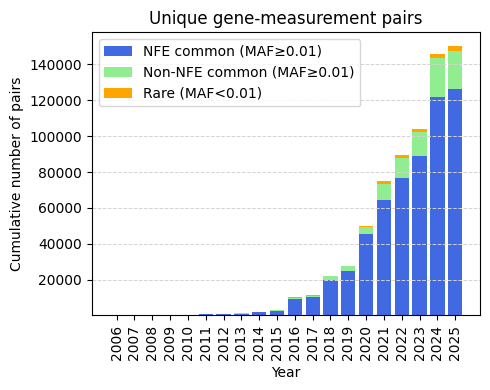

In [ ]:
plot_cumulative_gene_disease_pairs(l2g_measurements_full, title="Unique gene-measurement pairs")


# Temporal dependenses of studies - needs to be updated!


In [31]:
l2g_full.count()


788767

In [ ]:
qm_cs = (
    session.spark.read.parquet(
        "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_measurement_credible_sets"
    )
    .select("studyLocusId")
    .cache()
)
qm_cs.count()


450357

In [ ]:
qd_cs = (
    session.spark.read.parquet("gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_credible_sets")
    .select("studyLocusId")
    .cache()
)
qd_cs.count()


70618

In [ ]:
q_cs = qm_cs.unionByName(qd_cs).distinct().cache()
q_cs.count()


520975

In [ ]:
si = si.df.withColumn(
    "publicationDate",
    f.when(f.col("projectId") == "FINNGEN_R12", f.lit("2024-11-04")).otherwise(f.col("publicationDate")),
).withColumn("year", f.col("publicationDate").substr(1, 4).cast("int"))


In [ ]:
sl_eff = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/ss60/gentropy-manuscript/chapters/variant-effect-prediction/25.07/lead_variant_effect"
)
sl_eff = (
    sl_eff.drop("leadVariantConsequence")
    .withColumn("absEstimatedBeta", f.abs(f.col("rescaledStatistics.estimatedBeta")))
    .withColumn("maf", f.col("majorLdPopulationMaf.value"))
)


In [ ]:
sl_eff = sl_eff.join(si.select("studyId", "year", "nSamples"), on="studyId", how="inner").cache()
sl_eff.count()


2833758

In [ ]:
qd_sl_eff = sl_eff.join(qd_cs, on="studyLocusId", how="inner").toPandas()
qd_sl_eff


,studyLocusId,studyId,variantId,variant,geneId,originalBeta,originalStandardError,locusStatistics,finemappingMethod,isTransQtl,...,majorLdPopulationMaf,majorLdPopulationAf,variantStatistics,studyStatistics,rescaledStatistics,traitFromSourceMappedIds,absEstimatedBeta,maf,year,nSamples
0,fa58d8b83bdefe17ff05a3e668143e47,FINNGEN_R12_RHEUMA_SEROPOS_WIDE,6_137968604_GA_G,"(6, 137968604, 137968605, DEL, GA, G, 1)",None,-0.065879,0.016054,"(4, 10511, 137968604, 137979115, 0.72995620893...",SuSie,None,...,"(0.22860658841347975, notFlipped)","(fin_adj, 0.22860658841347975)","(32.41221759828355, 1.246999979019165, -8, 6.4...","(11918, 488425, 500343, Seropositive rheumatoi...","(-, -5.693172893763507, 0.3526912322948592, 0....",[EFO_0009459],0.088877,0.228607,2024,500343
1,5fcc9a55d2ad67bc8a0d888a8c6a0de4,FINNGEN_R12_KRA_PSY_ANYMENTAL,4_34490532_A_G,"(4, 34490532, 34490532, SNV, A, G, 0)",None,0.000814,0.005664,"(77, 122230, 34372047, 34494277, 0.02653346157...",SuSie,None,...,"(0.20983916745506148, notFlipped)","(fin_adj, 0.20983916745506148)","(34.09930379497642, 5.236999988555908, -9, 6.8...","(138044, 362304, 500348, Any mental disorder, ...","(+, 5.839460916469638, 0.3316133825136563, 0.2...",[EFO_0000677],0.032074,0.209839,2024,500348
2,031bf87f29ff27c98fc0c3cdfa8b7c68,FINNGEN_R12_J10_LARYNGITIS,5_119341087_CT_C,"(5, 119341087, 119341088, DEL, CT, C, 1)",None,0.011620,0.019689,"(53, 223820, 119341087, 119564907, 0.112447706...",SuSie,None,...,"(0.3067532467532468, notFlipped)","(fin_adj, 0.3067532467532468)","(30.26173661734319, 3.7750000953674316, -8, 7....","(6038, 402652, 408690, Acute laryngitis and tr...","(+, 5.501066861740838, 0.42531138471917695, 0....","[MONDO_0004777, EFO_0007518]",0.109365,0.306753,2024,408690
3,f40cfe72a887c6004b7f1cf132361de0,GCST010043,12_120840463_G_A,"(12, 120840463, 120840463, SNV, G, A, 0)",None,NaN,NaN,"(108, 185206, 120749754, 120934960, 0.21855323...",PICS,None,...,"(0.43050113425448544, notFlipped)","(nfe_adj, 0.43050113425448544)","(63.06496558949794, 2.0, -15, 0.00011758283490...","(88486, 447859, 536345, Asthma, gwas, binary, ...","(+, 7.941345326170997, 0.4903398153201739, 0.1...",[MONDO_0004979],0.041721,0.430501,2020,536345
4,3ee04490cd4a16b50fb8fd997bbc5059,GCST011320,2_65049318_T_C,"(2, 65049318, 65049318, SNV, T, C, 0)",None,NaN,NaN,"(59, 79695, 65048915, 65128610, 0.096786094325...",PICS,None,...,"(0.3849142117190029, notFlipped)","(nfe_adj, 0.3849142117190029)","(33.27511121226366, 8.0, -9, 4.150972804172497...","(142086, 659536, 801622, Type 2 diabetes or pr...","(+, 5.768458304630767, 0.47351052267148297, 0....","[EFO_0001663, MONDO_0005148]",0.024518,0.384914,2020,801622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70613,486237111321764b2dad47723dcf3e3e,GCST002069,2_191075725_G_A,"(2, 191075725, 191075725, SNV, G, A, 0)",None,0.277632,NaN,"(6, 21519, 191075725, 191097244, 0.50767474031...",PICS,None,...,"(0.1761228271419748, flipped)","(nfe_adj, 0.8238771728580252)","(44.176904562258294, 3.0, -11, 0.0040488410376...","(3530, 7381, 10911, Systemic lupus erythematos...","(+, 6.646570887477113, 0.29020715380298573, 0....","[EFO_0000717, MONDO_0007915]",0.252482,0.176123,2013,10911
70614,7850fa25aef091dcaf469f59f9bd58e3,GCST90432062,16_52591288_A_G,"(16, 52591288, 52591288, SNV, A, G, 0)",None,-0.151246,0.010204,"(43, 19915, 52590623, 52610538, 0.085678961907...",PICS,None,...,"(0.42174949245299675, notFlipped)","(nfe_adj, 0.42174949245299675)","(318.5482719432024, 3.0, -71, 0.00043052416238...","(38314, 701594, 739908, Restless legs syndrome...","(-, -17.847920661612164, 0.48775371613727275, ...",[EFO_0004270],0.134077,0.421749,2024,739908
70615,946eca3e297835f8db50821ebcb87fb2,GCST90044699,8_27608798_T_C,"(8, 27608798, 27608798, SNV, T, C, 0)",None,NaN,NaN,"(9, 5340, 27604964, 27610304, 0.3157721142532796)",PICS,None,...,"(0.391727202119883, flipped)","(nfe_adj, 0.608272797880117)","(94.90247129530754, 2.0, -22, 8.42407138307467...","(903

In [ ]:
qm_sl_eff = sl_eff.join(qm_cs, on="studyLocusId", how="inner").toPandas()
qm_sl_eff


,studyLocusId,studyId,variantId,variant,geneId,originalBeta,originalStandardError,locusStatistics,finemappingMethod,isTransQtl,...,majorLdPopulationMaf,majorLdPopulationAf,variantStatistics,studyStatistics,rescaledStatistics,traitFromSourceMappedIds,absEstimatedBeta,maf,year,nSamples
0,0005218bc3a62e3875f2ba0a0b63c349,GCST90014010,19_38320104_C_G,"(19, 38320104, 38320104, SNV, C, G, 0)",None,-0.008428,NaN,"(1, 0, 38320104, 38320104, 0.994477700425251)",SuSiE-inf,None,...,"(0.02581275253566422, notFlipped)","(nfe_adj, 0.02581275253566422)","(25.385473285903018, 4.694398880004883, -7, 7....","(0, 0, 357302, Phosphate levels (UKB data fiel...","(-, -5.038399873561349, 0.05029290868439356, 0...",[EFO_0010968],0.037586,0.025813,2021,357302
1,00063cca492e89f3908e7933e3f4782c,GCST90445976,5_156964617_T_C,"(5, 156964617, 156964617, SNV, T, C, 0)",None,-0.786459,NaN,"(1, 0, 156964617, 156964617, 0.9999947375610869)",SuSiE-inf,None,...,"(0.3727304828885031, flipped)","(nfe_adj, 0.6272695171114969)","(71.00558509701784, 3.562150716781616, -17, 0....","(0, 0, 94271, Phospholipids in medium LDL (UKB...","(-, -8.426481181194072, 0.4676049400284128, 0....",[EFO_0022183],0.040134,0.372730,2024,94271
2,000eb6efa1c5c2c1c7ae20d2af8f0320,GCST90445998,19_19614279_T_C,"(19, 19614279, 19614279, SNV, T, C, 0)",None,1.131101,NaN,"(1, 0, 19614279, 19614279, 1.0)",SuSiE-inf,None,...,"(0.2564939840555408, flipped)","(nfe_adj, 0.7435060159444592)","(31.969852996385388, 1.5658385753631592, -8, 0...","(0, 0, 94420, Omega-3 fatty acids levels (UKB ...","(+, 5.654188977774389, 0.3814096403977136, 0.0...",[EFO_0010119],0.029795,0.256494,2024,94420
3,000f11fd8f1f27c0d0a84c8775861e83,GCST008996,10_27615392_C_T,"(10, 27615392, 27615392, SNV, C, T, 0)",None,-0.010600,0.001786,"(97, 47433, 27615328, 27662761, 0.078699207619...",PICS,None,...,"(0.4085478887744593, notFlipped)","(nfe_adj, 0.4085478887744593)","(34.6237314366779, 4.0, -9, 4.962311057892822e...","(0, 0, 697734, Waist-hip ratio, gwas, quantita...","(-, -5.884193354800461, 0.4832730227047826, 0....",[EFO_0004343],0.010133,0.408548,2018,697734
4,001466807bf964c8a7924ccf9959bdd6,GCST007069,1_62437203_A_G,"(1, 62437203, 62437203, SNV, A, G, 0)",None,NaN,NaN,"(6, 246966, 62437203, 62684169, 0.475812599681...",PICS,None,...,"(0.40887033216148483, flipped)","(nfe_adj, 0.5911296678385152)","(56.371292705053975, 6.0, -14, 0.0001266770622...","(0, 0, 445000, Red blood cell count, gwas, qua...","(+, 7.508081825942893, 0.48339076727928376, 0....",[EFO_0004305],0.016188,0.408870,2018,445000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450352,ff4df0caadfc9701247b69056c862829,GCST90566731,12_240132_C_T,"(12, 240132, 240132, SNV, C, T, 0)",None,-2.600680,0.253242,"(3, 513, 239619, 240132, 0.6822456013680405)",PICS,None,...,"(0.3489022308552593, flipped)","(nfe_adj, 0.6510977691447407)","(105.45005916001735, 9.732000350952148, -25, 0...","(0, 0, 413798, Estimated glomerular filtration...","(-, -10.268887922263897, 0.4543389283189653, 0...",[OBA_0003747],0.023683,0.348902,2025,413798
450353,ff51b67af87ae62250360a96719027ad,GCST90479668,13_40904827_G_A,"(13, 40904827, 40904827, SNV, G, A, 0)",None,-0.009782,NaN,"(29, 403506, 40579448, 40982954, 0.62875874754...",SuSiE-inf,None,...,"(0.14587684975434673, notFlipped)","(nfe_adj, 0.14587684975434673)","(42.22959672862835, 8.116236686706543, -11, 0....","(0, 0, 417277, lymphocyte (fraction, minimum, ...","(-, -6.498430328058334, 0.24919358892018895, 0...",[EFO_0004587],0.020152,0.145877,2024,417277
450354,ff6eedeb4998ec458f2d35807f69a78a,GCST90479714,1_68054537_G_C,"(1, 68054537, 68054537, SNV, G, C, 0)",None,0.343033,NaN,"(1, 0, 68054537, 68054537, 1.0)",SuSiE-inf,None,...,"(0.010001470804530078, notFlipped)","(nfe_adj, 0.010001470804530078)","(41.23054979719135, 1.3529140949249268, -10, 0...","(0, 0, 369386, neutrophil (fraction, mean, inv...","(+, 6.421101914561967, 0.019802882772552422, 0...",[EFO_0004833],0.075077,0.010001,2024,

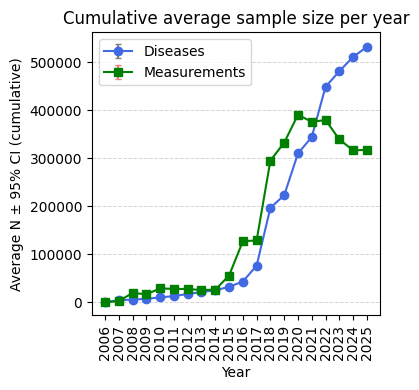

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


def get_cumulative_stats(df, value_col="nSamples"):
    years = sorted(df["year"].unique())
    results = []
    for y in years:
        df_up_to_year = df[df["year"] <= y]
        N = df_up_to_year.shape[0]
        mean = df_up_to_year[value_col].mean()
        se = df_up_to_year[value_col].std() / (N**0.5) if N > 0 else 0
        ci = 1.96 * se
        results.append({"year": y, "mean": mean, "ci": ci})
    stats_df = pd.DataFrame(results)
    stats_df["year"] = stats_df["year"].astype(int).astype(str)
    return stats_df


stats_qd = get_cumulative_stats(qd_sl_eff)
stats_qm = get_cumulative_stats(qm_sl_eff)

plt.figure(figsize=(4, 4))
plt.errorbar(
    stats_qd["year"],
    stats_qd["mean"],
    yerr=stats_qd["ci"],
    fmt="o-",
    color="royalblue",
    ecolor="gray",
    capsize=2,
    label="Diseases",
)
plt.errorbar(
    stats_qm["year"],
    stats_qm["mean"],
    yerr=stats_qm["ci"],
    fmt="s-",
    color="green",
    ecolor="lightcoral",
    capsize=2,
    label="Measurements",
)
plt.xlabel("Year")
plt.ylabel("Average N ± 95% CI (cumulative)")
plt.title("Cumulative average sample size per year")
plt.legend()
plt.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.7)
plt.xticks(rotation=90)
plt.tight_layout()


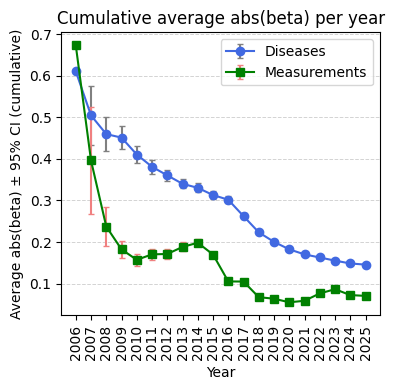

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


def get_cumulative_stats(df, value_col="absEstimatedBeta"):
    years = sorted(df["year"].unique())
    results = []
    for y in years:
        df_up_to_year = df[df["year"] <= y]
        N = df_up_to_year.shape[0]
        mean = df_up_to_year[value_col].mean()
        se = df_up_to_year[value_col].std() / (N**0.5) if N > 0 else 0
        ci = 1.96 * se
        results.append({"year": y, "mean": mean, "ci": ci})
    stats_df = pd.DataFrame(results)
    stats_df["year"] = stats_df["year"].astype(int).astype(str)
    return stats_df


stats_qd = get_cumulative_stats(qd_sl_eff)
stats_qm = get_cumulative_stats(qm_sl_eff)

plt.figure(figsize=(4, 4))
plt.errorbar(
    stats_qd["year"],
    stats_qd["mean"],
    yerr=stats_qd["ci"],
    fmt="o-",
    color="royalblue",
    ecolor="gray",
    capsize=2,
    label="Diseases",
)
plt.errorbar(
    stats_qm["year"],
    stats_qm["mean"],
    yerr=stats_qm["ci"],
    fmt="s-",
    color="green",
    ecolor="lightcoral",
    capsize=2,
    label="Measurements",
)
plt.xlabel("Year")
plt.ylabel("Average abs(beta) ± 95% CI (cumulative)")
plt.title("Cumulative average abs(beta) per year")
plt.legend()
plt.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.7)
plt.xticks(rotation=90)
plt.tight_layout()


In [ ]:
qd_sl_eff.to_csv("./data/qd_sl_eff.csv", index=False)
qm_sl_eff.to_csv("./data/qm_sl_eff.csv", index=False)


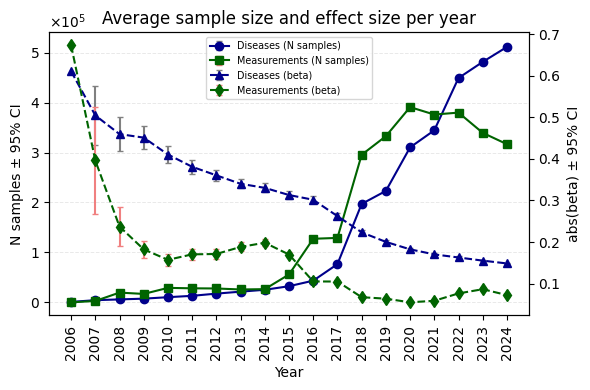

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import ScalarFormatter


def get_cumulative_stats(df, value_col="absEstimatedBeta"):
    # Filter out 2025 data
    df = df[df["year"] != 2025]

    years = sorted(df["year"].unique())
    results = []
    for y in years:
        df_up_to_year = df[df["year"] <= y]
        N = df_up_to_year.shape[0]
        mean = df_up_to_year[value_col].mean()
        se = df_up_to_year[value_col].std() / (N**0.5) if N > 0 else 0
        ci = 1.96 * se
        results.append({"year": y, "mean": mean, "ci": ci})
    stats_df = pd.DataFrame(results)
    stats_df["year"] = stats_df["year"].astype(int).astype(str)
    return stats_df


# Calculate stats for sample size
stats_qd_samples = get_cumulative_stats(qd_sl_eff, "nSamples")
stats_qm_samples = get_cumulative_stats(qm_sl_eff, "nSamples")

# Calculate stats for abs(beta)
stats_qd_beta = get_cumulative_stats(qd_sl_eff, "absEstimatedBeta")
stats_qm_beta = get_cumulative_stats(qm_sl_eff, "absEstimatedBeta")

# Create figure with dual y-axes
fig, ax1 = plt.subplots(figsize=(6, 4))

# Plot sample size on left y-axis
ax1.errorbar(
    stats_qd_samples["year"],
    stats_qd_samples["mean"],
    yerr=stats_qd_samples["ci"],
    fmt="o-",
    color="darkblue",
    ecolor="gray",
    capsize=2,
    label="Diseases (N samples)",
)
ax1.errorbar(
    stats_qm_samples["year"],
    stats_qm_samples["mean"],
    yerr=stats_qm_samples["ci"],
    fmt="s-",
    color="darkgreen",
    ecolor="lightcoral",
    capsize=2,
    label="Measurements (N samples)",
)
ax1.set_xlabel("Year")
ax1.set_ylabel("N samples ± 95% CI", color="black")

# Format left y-axis to use scientific notation for large numbers
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 2))  # Use scientific notation for numbers outside 10^-1 to 10^2
ax1.yaxis.set_major_formatter(formatter)

ax1.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.7, alpha=0.5)
ax1.tick_params(axis="x", rotation=90)

# Create second y-axis for abs(beta)
ax2 = ax1.twinx()
ax2.errorbar(
    stats_qd_beta["year"],
    stats_qd_beta["mean"],
    yerr=stats_qd_beta["ci"],
    fmt="^--",
    color="darkblue",
    ecolor="gray",
    capsize=2,
    label="Diseases (beta)",
)
ax2.errorbar(
    stats_qm_beta["year"],
    stats_qm_beta["mean"],
    yerr=stats_qm_beta["ci"],
    fmt="d--",
    color="darkgreen",
    ecolor="lightcoral",
    capsize=2,
    label="Measurements (beta)",
)
ax2.set_ylabel("abs(beta) ± 95% CI", color="black")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", fontsize="x-small")

plt.title("Average sample size and effect size per year")
plt.tight_layout()
plt.show()


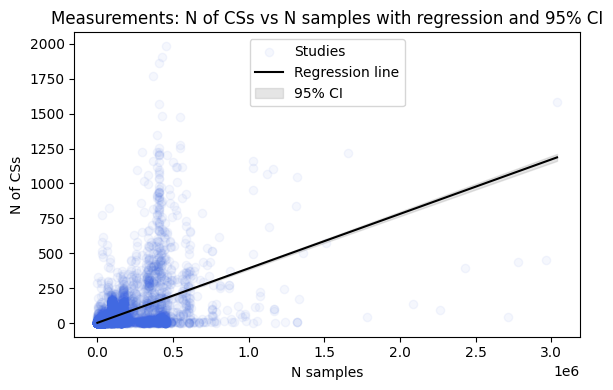

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t
from sklearn.linear_model import LinearRegression

# Prepare data: count rows per studyId
study_counts = qm_sl_eff.groupby("studyId").size().reset_index(name="num_rows")
study_stats = qm_sl_eff.groupby("studyId")["nSamples"].first().reset_index()
df_plot = pd.merge(study_counts, study_stats, on="studyId")

# Sort by nSamples for plotting
df_plot = df_plot.sort_values("nSamples")

# Scatter plot with transparent dots
plt.figure(figsize=(6, 4))
plt.scatter(df_plot["nSamples"], df_plot["num_rows"], alpha=0.05, color="royalblue", label="Studies")

# Fit regression line
X = df_plot["nSamples"].values.reshape(-1, 1)
y = df_plot["num_rows"].values
reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)

# Plot regression line
plt.plot(df_plot["nSamples"], y_pred, color="black", label="Regression line")

# Calculate 95% confidence interval for regression
n = len(y)
y_mean = np.mean(y)
X_mean = np.mean(X)
se_reg = np.sqrt(np.sum((y - y_pred) ** 2) / (n - 2)) / np.sqrt(np.sum((X.flatten() - X_mean) ** 2))
t_val = t.ppf(0.975, n - 2)
ci = t_val * se_reg * (df_plot["nSamples"] - X_mean)
upper = y_pred + ci
lower = y_pred - ci

# Plot confidence interval shading
plt.fill_between(df_plot["nSamples"], lower, upper, color="gray", alpha=0.2, label="95% CI")

plt.xlabel("N samples")
plt.ylabel("N of CSs")
plt.title("Measurements: N of CSs vs N samples with regression and 95% CI")
plt.legend()
plt.tight_layout()
plt.show()


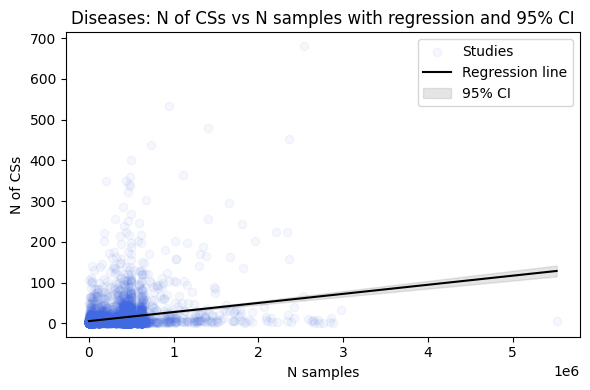

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t
from sklearn.linear_model import LinearRegression

# Prepare data: count rows per studyId
study_counts = qd_sl_eff.groupby("studyId").size().reset_index(name="num_rows")
study_stats = qd_sl_eff.groupby("studyId")["nSamples"].first().reset_index()
df_plot = pd.merge(study_counts, study_stats, on="studyId")

# Sort by nSamples for plotting
df_plot = df_plot.sort_values("nSamples")

# Scatter plot with transparent dots
plt.figure(figsize=(6, 4))
plt.scatter(df_plot["nSamples"], df_plot["num_rows"], alpha=0.05, color="royalblue", label="Studies")

# Fit regression line
X = df_plot["nSamples"].values.reshape(-1, 1)
y = df_plot["num_rows"].values
reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)

# Plot regression line
plt.plot(df_plot["nSamples"], y_pred, color="black", label="Regression line")

# Calculate 95% confidence interval for regression
n = len(y)
y_mean = np.mean(y)
X_mean = np.mean(X)
se_reg = np.sqrt(np.sum((y - y_pred) ** 2) / (n - 2)) / np.sqrt(np.sum((X.flatten() - X_mean) ** 2))
t_val = t.ppf(0.975, n - 2)
ci = t_val * se_reg * (df_plot["nSamples"] - X_mean)
upper = y_pred + ci
lower = y_pred - ci

# Plot confidence interval shading
plt.fill_between(df_plot["nSamples"], lower, upper, color="gray", alpha=0.2, label="95% CI")

plt.xlabel("N samples")
plt.ylabel("N of CSs")
plt.title("Diseases: N of CSs vs N samples with regression and 95% CI")
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/p5/4t9crp1563l792qz8xz_3x5h0000gq/T/ipykernel_75530/2867047669.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



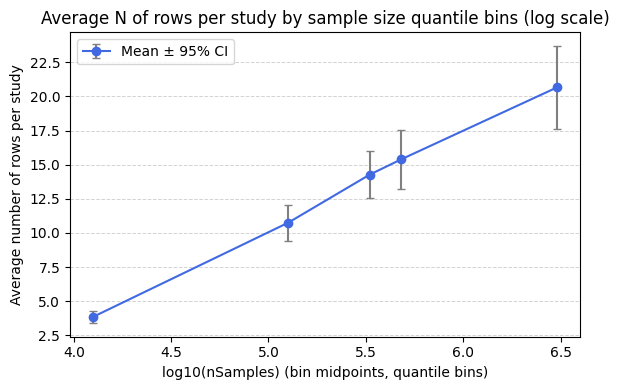

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Divide studies into 10 bins with equal number of studies (quantiles)
df_plot["nSamples_bin"] = pd.qcut(df_plot["nSamples"], q=5, duplicates="drop")

# For each bin, calculate mean and SE of num_rows
bin_stats = df_plot.groupby("nSamples_bin")["num_rows"].agg(["mean", "count", "std"]).reset_index()
bin_stats["se"] = bin_stats["std"] / np.sqrt(bin_stats["count"])
bin_stats["ci"] = bin_stats["se"] * 1.96

# Ensure bin_mid is float dtype before log10
bin_stats["bin_mid"] = bin_stats["nSamples_bin"].apply(lambda x: (float(x.left) + float(x.right)) / 2)
bin_stats["bin_mid"] = bin_stats["bin_mid"].astype(float)
bin_stats["bin_mid_log"] = np.log10(bin_stats["bin_mid"].values)

plt.figure(figsize=(6, 4))
plt.errorbar(
    bin_stats["bin_mid_log"],
    bin_stats["mean"],
    yerr=bin_stats["ci"],
    fmt="o-",
    color="royalblue",
    ecolor="gray",
    capsize=3,
    label="Mean ± 95% CI",
)
plt.xlabel("log10(nSamples) (bin midpoints, quantile bins)")
plt.ylabel("Average number of rows per study")
plt.title("Average N of rows per study by sample size quantile bins (log scale)")
plt.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.7)
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/p5/4t9crp1563l792qz8xz_3x5h0000gq/T/ipykernel_75530/4233099466.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/p5/4t9crp1563l792qz8xz_3x5h0000gq/T/ipykernel_75530/4233099466.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



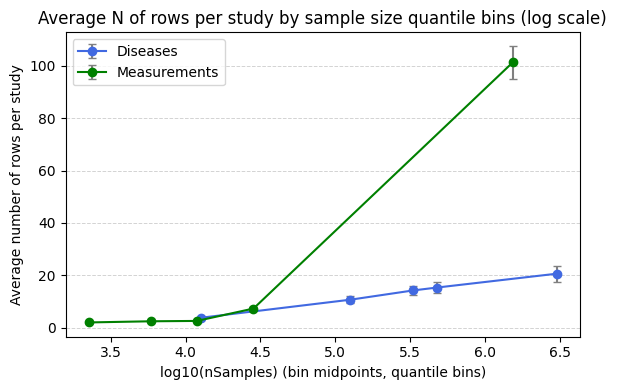

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_bins(df, label, color):
    # Bin nSamples into 10 quantile bins
    df_plot = df.groupby("studyId").size().reset_index(name="num_rows")
    study_stats = df.groupby("studyId")["nSamples"].first().reset_index()
    df_plot = pd.merge(df_plot, study_stats, on="studyId")
    df_plot["nSamples_bin"] = pd.qcut(df_plot["nSamples"], q=5, duplicates="drop")
    bin_stats = df_plot.groupby("nSamples_bin")["num_rows"].agg(["mean", "count", "std"]).reset_index()
    bin_stats["se"] = bin_stats["std"] / np.sqrt(bin_stats["count"])
    bin_stats["ci"] = bin_stats["se"] * 1.96
    # Convert bin_mid to float and then to numpy array before log10
    bin_stats["bin_mid"] = bin_stats["nSamples_bin"].apply(lambda x: (float(x.left) + float(x.right)) / 2)
    bin_mid_np = bin_stats["bin_mid"].astype(float).to_numpy()
    bin_stats["bin_mid_log"] = np.log10(bin_mid_np)
    plt.errorbar(
        bin_stats["bin_mid_log"],
        bin_stats["mean"],
        yerr=bin_stats["ci"],
        fmt="o-",
        color=color,
        ecolor="gray",
        capsize=3,
        label=label,
    )


plt.figure(figsize=(6, 4))
plot_bins(qd_sl_eff, "Diseases", "royalblue")
plot_bins(qm_sl_eff, "Measurements", "green")
plt.xlabel("log10(nSamples) (bin midpoints, quantile bins)")
plt.ylabel("Average number of rows per study")
plt.title("Average N of rows per study by sample size quantile bins (log scale)")
plt.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.7)
plt.legend()
plt.tight_layout()
plt.show()


# Pleyotopicity of genes


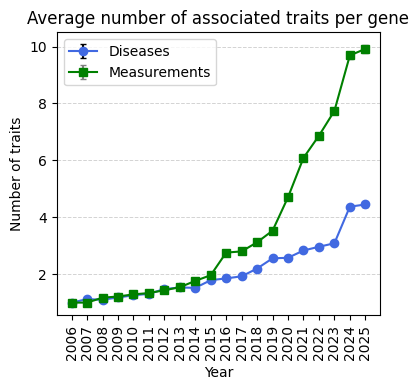

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


def get_cumulative_disease_stats(df):
    years = sorted(df["year"].unique())
    results = []
    for y in years:
        df_up_to_year = df[df["year"] <= y]
        exploded = df_up_to_year.explode("diseaseIds")
        counts = exploded.groupby("geneId")["diseaseIds"].nunique()
        N = counts.shape[0]
        mean = counts.mean()
        se = counts.std() / (N**0.5) if N > 0 else 0
        results.append({"year": y, "mean": mean, "se": se})
    stats_df = pd.DataFrame(results)
    stats_df["year"] = stats_df["year"].astype(int).astype(str)
    return stats_df


stats_qd = get_cumulative_disease_stats(qd_l2g_full)
stats_qm = get_cumulative_disease_stats(qm_l2g_full)

plt.figure(figsize=(4, 4))
plt.errorbar(
    stats_qd["year"],
    stats_qd["mean"],
    yerr=stats_qd["se"],
    fmt="o-",
    color="royalblue",
    ecolor="black",
    capsize=2,
    label="Diseases",
)
plt.errorbar(
    stats_qm["year"],
    stats_qm["mean"],
    yerr=stats_qm["se"],
    fmt="s-",
    color="green",
    ecolor="gray",
    capsize=2,
    label="Measurements",
)
plt.xlabel("Year")
plt.ylabel("Number of traits")
plt.title("Average number of associated traits per gene")
plt.legend()
plt.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.7)
plt.xticks(rotation=90)
plt.tight_layout()


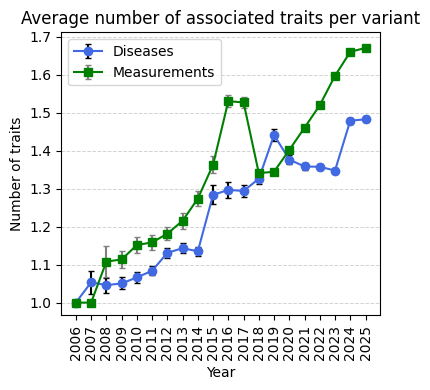

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


def get_cumulative_disease_stats(df):
    years = sorted(df["year"].unique())
    results = []
    for y in years:
        df_up_to_year = df[df["year"] <= y]
        exploded = df_up_to_year.explode("diseaseIds")
        counts = exploded.groupby("variantId")["diseaseIds"].nunique()
        N = counts.shape[0]
        mean = counts.mean()
        se = counts.std() / (N**0.5) if N > 0 else 0
        results.append({"year": y, "mean": mean, "se": se})
    stats_df = pd.DataFrame(results)
    stats_df["year"] = stats_df["year"].astype(int).astype(str)
    return stats_df


stats_qd = get_cumulative_disease_stats(qd_l2g_full)
stats_qm = get_cumulative_disease_stats(qm_l2g_full)

plt.figure(figsize=(4, 4))
plt.errorbar(
    stats_qd["year"],
    stats_qd["mean"],
    yerr=stats_qd["se"],
    fmt="o-",
    color="royalblue",
    ecolor="black",
    capsize=2,
    label="Diseases",
)
plt.errorbar(
    stats_qm["year"],
    stats_qm["mean"],
    yerr=stats_qm["se"],
    fmt="s-",
    color="green",
    ecolor="gray",
    capsize=2,
    label="Measurements",
)
plt.xlabel("Year")
plt.ylabel("Number of traits")
plt.title("Average number of associated traits per variant")
plt.legend()
plt.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.7)
plt.xticks(rotation=90)
plt.tight_layout()


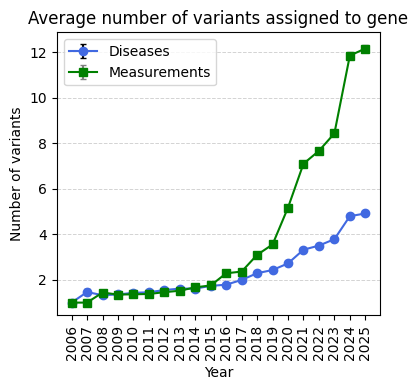

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


def get_cumulative_variant_stats(df):
    years = sorted(df["year"].unique())
    results = []
    for y in years:
        df_up_to_year = df[df["year"] <= y]
        counts = df_up_to_year.groupby("geneId")["variantId"].nunique()
        N = counts.shape[0]
        mean = counts.mean()
        std = counts.std()
        se = std / (N**0.5) if N > 0 else 0
        results.append({"year": y, "mean": mean, "se": se})
    stats_df = pd.DataFrame(results)
    stats_df["year"] = stats_df["year"].astype(int).astype(str)
    return stats_df


stats_qd = get_cumulative_variant_stats(qd_l2g_full)
stats_qm = get_cumulative_variant_stats(qm_l2g_full)

plt.figure(figsize=(4, 4))
plt.errorbar(
    stats_qd["year"],
    stats_qd["mean"],
    yerr=stats_qd["se"],
    fmt="o-",
    color="royalblue",
    ecolor="black",
    capsize=2,
    label="Diseases",
)
plt.errorbar(
    stats_qm["year"],
    stats_qm["mean"],
    yerr=stats_qm["se"],
    fmt="s-",
    color="green",
    ecolor="gray",
    capsize=2,
    label="Measurements",
)
plt.xlabel("Year")
plt.title("Average number of variants assigned to gene")
plt.ylabel("Number of variants")
plt.legend()
plt.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.7)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
